# CS506 Project Check-In (March): Boston Rent Prediction


- Preliminary visualizations  
- Data processing summary (what I have done so far)  
- Modeling methods used so far  
- Preliminary results + interpretation  

Dataset used: `ma_boston_housing.csv` (Boston area listings filtered from the housing dataset) `housing.csv`(US housing dataset that I downloaded from kaggle)


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "../data/ma_boston_housing.csv"  # adjust if needed
df = pd.read_csv(DATA_PATH)

df.head()


,id,url,region,region_url,price,type,sqfeet,beds,baths,cats_allowed,...,wheelchair_access,electric_vehicle_charge,comes_furnished,laundry_options,parking_options,image_url,description,lat,long,state
0,7048591916,https://boston.craigslist.org/gbs/apa/d/waverl...,boston,https://boston.craigslist.org,2450,apartment,950,2,2.0,1,...,0,0,0,laundry on site,off-street parking,https://images.craigslist.org/00Y0Y_4Nw47FbvqM...,Contact info: Owned and Managed by The Hamilt...,42.4235,-71.2166,ma
1,7048584795,https://boston.craigslist.org/bmw/apa/d/concor...,boston,https://boston.craigslist.org,1747,apartment,975,2,2.0,1,...,0,0,0,w/d in unit,off-street parking,https://images.craigslist.org/00O0O_hgVU1Dt4yZ...,"The Prescott at Concord 1 Nathan Pratt Drive, ...",42.4567,-71.3747,ma
2,7048579724,https://boston.craigslist.org/bmw/apa/d/concor...,boston,https://boston.craigslist.org,1667,apartment,719,1,1.0,1,...,0,0,0,w/d in unit,off-street parking,https://images.craigslist.org/00O0O_hgVU1Dt4yZ...,DISTINCT DESIGN IN A RURAL OASIS When it comes...,42.4567,-71.3747,ma
3,7038629072,https://boston.craigslist.org/sob/apa/d/stough...,boston,https://boston.craigslist.org,2400,condo,1400,3,1.5,1,...,0,0,0,laundry on site,attached garage,https://images.craigslist.org/00P0P_3xUxq7idjZ...,This condo is 3 bedroom unit with 1.5 bathroom...,42.1399,-71.1329,ma
4,7041351743,https://boston.craigslist.org/gbs/apa/d/revere...,boston,https://boston.craigslist.org,2400,apartment,1100,2,2.0,1,...,1,0,0,laundry in bldg,attached garage,https://images.craigslist.org/00l0l_8I60XIFhZF...,"2 bedrooms available. Heat, AC, and Hot Water ...",42.4138,-71.0052,ma


## Data Processing Done So Far (Summary)

**Filtering**
- Filtered the full USA housing listings dataset to `state == "ma"`.
- Further filtered to `region == "boston"` (Boston area listings).

**Cleaning**
- Converted key columns to numeric: `price`, `beds`, `baths`, `sqfeet`.
- Removed listings with invalid or missing `price`.
- Removed extreme price outliers (kept prices between **$500** and **$15,000**).
- Deduplicated listings using the listing `id`.

These steps reduce noise and create a cleaner dataset for modeling.


In [11]:
print("Shape:", df.shape)
df[["price", "beds", "baths", "sqfeet"]].describe()


Shape: (1576, 22)


,price,beds,baths,sqfeet
count,1576.000000,1576.000000,1576.000000,1576.000000
mean,2394.010152,1.905457,1.295051,1698.451777
std,871.744157,0.991684,0.520562,25172.232522
min,550.000000,0.000000,0.000000,0.000000
25%,1800.000000,1.000000,1.000000,750.000000
50%,2239.000000,2.000000,1.000000,989.000000
75%,2800.000000,2.000000,2.000000,1232.500000
max,10000.000000,6.000000,4.500000,999999.000000


## Preliminary Visualizations



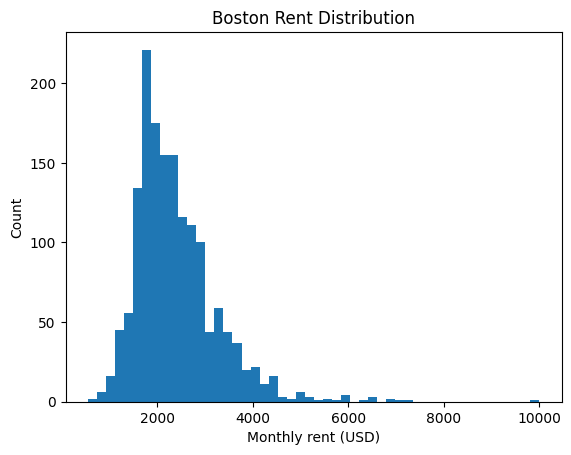

/var/folders/r8/ml4vhxjs71s5ynx4vpchtp_m0000gn/T/ipykernel_79897/3228484520.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


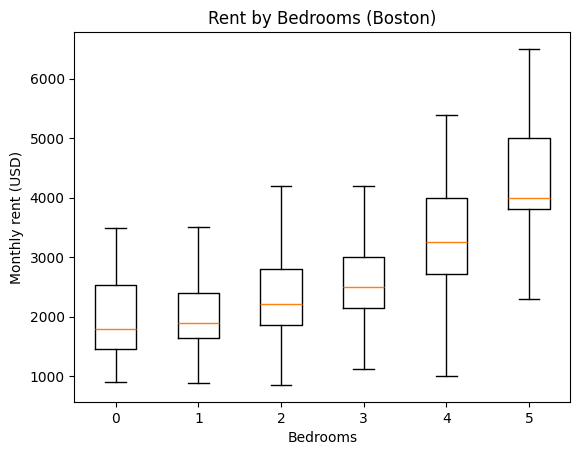

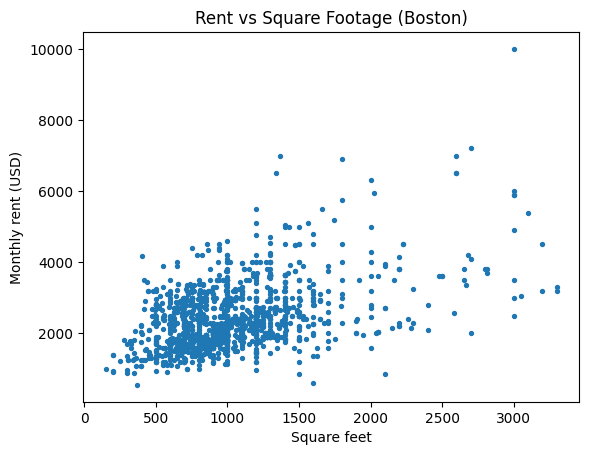

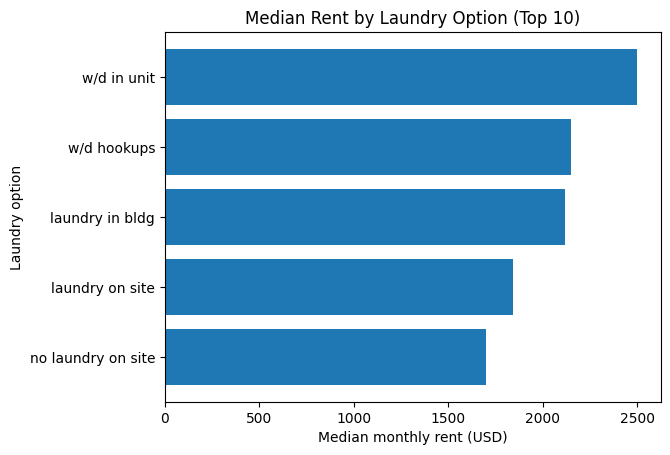

In [12]:
import matplotlib.pyplot as plt

# 1) Rent distribution
plt.figure()
plt.hist(df["price"], bins=50)
plt.title("Boston Rent Distribution")
plt.xlabel("Monthly rent (USD)")
plt.ylabel("Count")
plt.show()


# 2) Rent by bedrooms (boxplot)
if "beds" in df.columns:
    beds_vals = sorted([b for b in df["beds"].dropna().unique() if b <= 5])
    groups = [df.loc[df["beds"] == b, "price"].dropna() for b in beds_vals]
    labels = [str(b) for b in beds_vals]
    plt.figure()
    plt.boxplot(groups, labels=labels, showfliers=False)
    plt.title("Rent by Bedrooms (Boston)")
    plt.xlabel("Bedrooms")
    plt.ylabel("Monthly rent (USD)")
    plt.show()

# 3) Rent vs square footage (scatter)
if "sqfeet" in df.columns:
    sub = df.dropna(subset=["sqfeet"]).copy()
    # remove extreme sqft outliers for readability (optional)
    sub = sub[(sub["sqfeet"] > 100) & (sub["sqfeet"] < 5000)]
    plt.figure()
    plt.scatter(sub["sqfeet"], sub["price"], s=8)
    plt.title("Rent vs Square Footage (Boston)")
    plt.xlabel("Square feet")
    plt.ylabel("Monthly rent (USD)")
    plt.show()

# 4) Median rent by laundry option (example categorical insight)
if "laundry_options" in df.columns:
    med = df.groupby("laundry_options")["price"].median().sort_values(ascending=False)
    med = med[med.index.notna()]
    # show top 10 categories
    med = med.head(10)
    plt.figure()
    plt.barh(list(med.index)[::-1], list(med.values)[::-1])
    plt.title("Median Rent by Laundry Option (Top 10)")
    plt.xlabel("Median monthly rent (USD)")
    plt.ylabel("Laundry option")
    plt.show()


## Modeling Methods Used So Far

**Task:** Predict monthly rent price (`price`) from listing features.

**Baseline**
always predict the median rent from the training set.




In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import KNeighborsRegressor

# Load
df = pd.read_csv("../data/ma_boston_housing.csv").copy()



# Make sure description exists (fill missing with empty string)
df["description"] = df["description"].fillna("").astype(str)

# Choose features
num_features = [c for c in ["beds", "baths", "sqfeet"] if c in df.columns]
cat_features = [c for c in ["type", "laundry_options", "parking_options"] if c in df.columns]
text_feature = "description"

X = df[num_features + cat_features + [text_feature]].copy()
y = df["price"].copy()

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# Baseline: median predictor
# -------------------------
baseline_pred = np.full(shape=len(y_test), fill_value=y_train.median())
baseline_mae = mean_absolute_error(y_test, baseline_pred)

print("Baseline (median) MAE:", round(baseline_mae, 2))

# -------------------------
# LSA + KNN Regression model
# -------------------------
# Text pipeline: TF-IDF -> SVD (LSA)
text_pipe = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=20000,   # safe cap
        min_df=5              # ignore very rare words
    )),
    ("svd", TruncatedSVD(n_components=100, random_state=42)),
    ("scale", StandardScaler())  # important for KNN distance
])

# Numeric pipeline: impute -> scale
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

# Categorical pipeline: impute -> one-hot
cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("text", text_pipe, text_feature),
        ("num", num_pipe, num_features),
        ("cat", cat_pipe, cat_features),
    ],
    remainder="drop"
)

knn = KNeighborsRegressor(
    n_neighbors=15,   # try 10, 15, 25 if you have time
    weights="distance"  # closer neighbors matter more
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("knn", knn)
])

model.fit(X_train, y_train)
pred = model.predict(X_test)

knn_mae = mean_absolute_error(y_test, pred)

print("LSA + KNN MAE:", round(knn_mae, 2))
print("Improvement (baseline - model):", round(baseline_mae - knn_mae, 2))


Baseline (median) MAE: 602.59
LSA + KNN MAE: 358.14
Improvement (baseline - model): 244.45


## Reason for KNN
I’m predicting monthly rent for a listing. Rent depends on obvious structured info like beds, baths, neighborhood, square footage, and amenities, but it also depends a lot on what the description says, like ‘luxury,’ ‘near T,’ or ‘utilities included.’ LSA helps me turn the description text into a small set of meaningful numbers so similar descriptions become close to each other. Then KNN fits the real-world idea of ‘comparable apartments’: to price a new listing, it finds the most similar listings and averages their rents. I chose KNN because it captures both the unit’s size/amenities and the quality signals that only show up in the text.



## Preliminary Results & Interpretation


**How to interpret MAE**
- MAE(Mean Absolute Error) is in dollars. For example, MAE = 300 means the model is off by about $300 on average.

I filtered the housing listings dataset to Boston, cleaned invalid prices, and kept core listing fields plus the text description. For modeling, I used LSA, meaning TF-IDF on the listing descriptions followed by SVD to reduce the text into dense semantic features. Then I applied KNN: for a new listing, it predicts rent using the average rent of the most similar listings in this feature space, along with structured features like beds, baths, and square footage.
As a baseline, predicting the median rent gives MAE = 602.59. My LSA + KNN model achieves MAE = 358.14, improving by $244 on average (about a 40% reduction). Next, I plan to tune K, test adding/removing structured features, and do deeper error analysis to see where the model performs poorly (e.g., high-end listing prices tend to vary significantly)

